# Locus-Level Enrichment Validation: Independent Corroboration of TRACERx Renal's Hallmark Loci

1. **Pre-specified primary test** — 9p and 14q only, the two loci Turajlic et al. explicitly named, tested at both the driver-SCNA-cytoband level (9p21.3, 14q31.1) and the broader arm level (9p, 14q), with Bonferroni correction for the small number of pre-specified comparisons.
2. **Exploratory systematic screen** — every locus in the driver-SCNA and arm-level SCNA sheets, tested with Benjamini-Hochberg FDR correction, reported in full regardless of outcome, to surface any additional candidates and to honestly show what does *not* replicate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

df = pd.read_csv("binary_selection_dataset.csv")
print(f"Dataset: {len(df)} events, {df['patient'].nunique()} patients")

Dataset: 1195 events, 37 patients


## 1. Pre-specified primary test: 9p and 14q loss

Tested at two resolutions available in the data:
- **Driver-SCNA cytoband level** (`9p21.3`, `14q31.1`) — the specific minimal driver regions
- **Arm level** (`9p`, `14q`) — the broader chromosome-arm event

4 comparisons total → Bonferroni-corrected significance threshold = 0.05/4 = 0.0125.

In [2]:
def test_locus(data, locus_col, locus, label_col="label"):
    sub = data[data[locus_col] == locus]
    rest = data[data[locus_col] != locus]
    a, b = sub[label_col].sum(), len(sub) - sub[label_col].sum()
    c, d = rest[label_col].sum(), len(rest) - rest[label_col].sum()
    odds, p = fisher_exact([[a, b], [c, d]])
    return {"locus": locus, "n": len(sub), "n_patients": sub["patient"].nunique(),
            "selection_rate": sub[label_col].mean(), "background_rate": rest[label_col].mean(),
            "odds_ratio": odds, "p_value": p}

scna = df[df["event_category"] == "driverSCNA"]
arm = df[df["event_category"] == "armSCNA"]

primary_tests = [
    test_locus(scna, "gene_or_locus", "9p21.3"),
    test_locus(scna, "gene_or_locus", "14q31.1"),
    test_locus(arm, "gene_or_locus", "9p"),
    test_locus(arm, "gene_or_locus", "14q"),
]
primary_df = pd.DataFrame(primary_tests)
primary_df["bonferroni_p"] = np.minimum(primary_df["p_value"] * 4, 1.0)
primary_df["significant_at_0.05_bonferroni"] = primary_df["bonferroni_p"] < 0.05
primary_df

,locus,n,n_patients,selection_rate,background_rate,odds_ratio,p_value,bonferroni_p,significant_at_0.05_bonferroni
0,9p21.3,33,20,0.636364,0.477064,1.918269,0.095943,0.383772,False
1,14q31.1,20,14,0.700000,0.480519,2.522523,0.066079,0.264316,False
2,9p,15,10,0.733333,0.343348,5.259375,0.004071,0.016286,True
3,14q,26,17,0.576923,0.343023,2.611710,0.020058,0.080233,False


## 2. Exploratory systematic screen (all loci, FDR-corrected)


In [3]:
def systematic_screen(data, locus_col, min_n=5):
    results = []
    for locus in data[locus_col].unique():
        sub = data[data[locus_col] == locus]
        if len(sub) < min_n:
            continue
        results.append(test_locus(data, locus_col, locus))
    res_df = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
    res_df["fdr_bh"] = multipletests(res_df["p_value"], method="fdr_bh")[1]
    return res_df

driver_screen = systematic_screen(scna, "gene_or_locus")
print("=== Driver-SCNA cytoband-level screen (14 loci tested) ===")
driver_screen

=== Driver-SCNA cytoband-level screen (14 loci tested) ===


,locus,n,n_patients,selection_rate,background_rate,odds_ratio,p_value,fdr_bh
0,8p23.2,11,10,0.000000,0.520833,0.000000,0.000778,0.010109
1,2q14.3,19,12,0.210526,0.521552,0.244628,0.015012,0.097575
2,14q31.1,20,14,0.700000,0.480519,2.522523,0.066079,0.266171
3,9p21.3,33,20,0.636364,0.477064,1.918269,0.095943,0.266171
4,5q35.3,9,6,0.777778,0.487603,3.677966,0.102373,0.266171
5,8q24.21,19,12,0.578947,0.491379,1.423246,0.485382,0.899780
6,4q34.3,21,12,0.428571,0.504348,0.737069,0.649455,0.899780
7,12p11.21,20,14,0.550000,0.493506,1.254386,0.649455,0.899780
8,20q13.33,26,15,0.538462,0.493333,1.198198,0.684419,0.899780
9,1q25.1,12,8,0.416667,0.502092,0.708333,0.768855,0.899780


In [4]:
arm_screen = systematic_screen(arm, "gene_or_locus")
print("=== Arm-level screen (48 arms tested) ===")
arm_screen.head(15)

=== Arm-level screen (48 arms tested) ===


,locus,n,n_patients,selection_rate,background_rate,odds_ratio,p_value,fdr_bh
0,17p,21,13,0.714286,0.340548,4.841102,0.000746,0.035808
1,11,14,9,0.000000,0.358571,0.000000,0.003205,0.065144
2,9p,15,10,0.733333,0.343348,5.259375,0.004071,0.065144
3,5q,7,5,0.857143,0.346535,11.314286,0.008936,0.102680
4,16q,12,7,0.000000,0.357550,0.000000,0.010696,0.102680
5,14q,26,17,0.576923,0.343023,2.611710,0.020058,0.160467
6,16,9,4,0.000000,0.356028,0.000000,0.030765,0.210962
7,19q,17,10,0.117647,0.357245,0.239893,0.041915,0.251488
8,12,15,9,0.600000,0.346209,2.832645,0.054744,0.264561
9,2,8,5,0.000000,0.355524,0.000000,0.055825,0.264561


## 3. Visualizing the screen


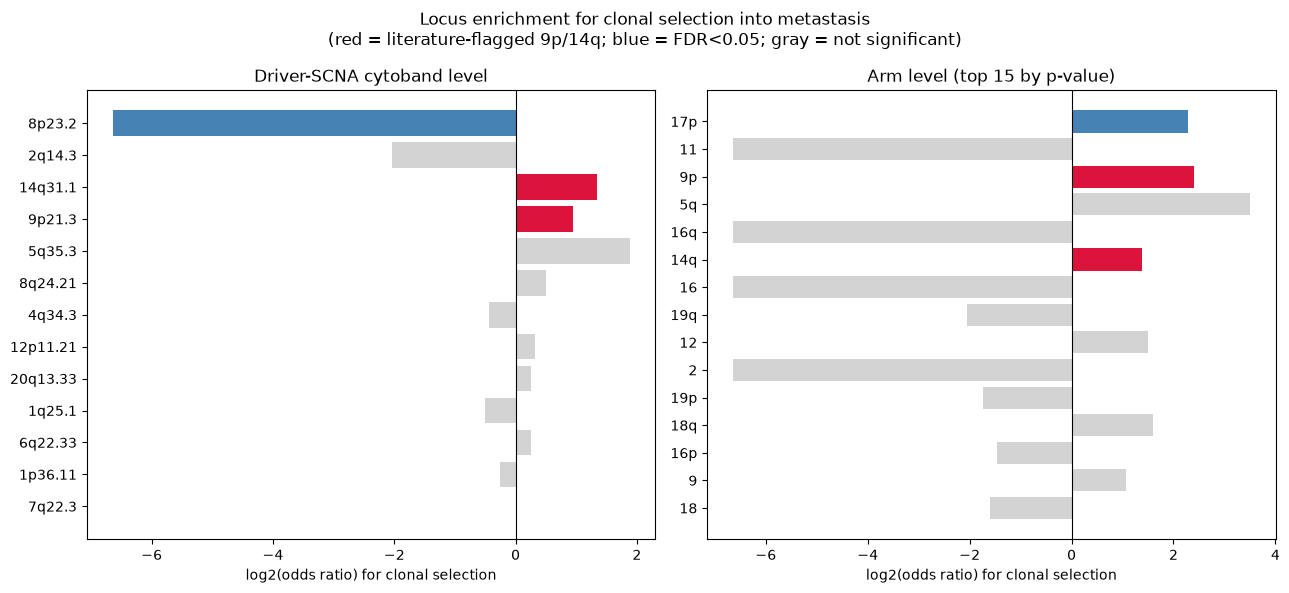

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, screen, title, highlight in [
    (axes[0], driver_screen, "Driver-SCNA cytoband level", ["9p21.3", "14q31.1"]),
    (axes[1], arm_screen.head(15), "Arm level (top 15 by p-value)", ["9p", "14q"]),
]:
    screen = screen.copy()
    screen["log_or"] = np.log2(screen["odds_ratio"].replace(0, 0.01))
    colors = ["crimson" if l in highlight else ("steelblue" if p < 0.05 else "lightgray")
              for l, p in zip(screen["locus"], screen["fdr_bh"])]
    ax.barh(screen["locus"], screen["log_or"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("log2(odds ratio) for clonal selection")
    ax.set_title(title)
    ax.invert_yaxis()

plt.suptitle("Locus enrichment for clonal selection into metastasis\n(red = literature-flagged 9p/14q; blue = FDR<0.05; gray = not significant)")
plt.tight_layout()

plt.savefig(
    'Figure7_locus_enrichment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 4. A closer look at the strongest unexpected finding: 8p23.2



In [6]:
locus_8p = scna[scna["gene_or_locus"] == "8p23.2"]
print(f"8p23.2 events: n={len(locus_8p)} across {locus_8p['patient'].nunique()} distinct patients")
print(locus_8p[["patient", "label", "met_site", "event_subtype"]].to_string(index=False))

8p23.2 events: n=11 across 10 distinct patients
patient  label      met_site event_subtype
   K191      0  THROMBUS_IVC          Loss
   K228      0  ADRENAL_IL_D          Loss
   K234      0   THROMBUS_RV          Loss
   K243      0   THROMBUS_RV          Loss
   K276      0   THROMBUS_RV          Loss
   K071      0    ADRENAL_IL          Loss
   K099      0   THROMBUS_RV          Loss
   K099      0  THROMBUS_IVC          Loss
   K167      0   THROMBUS_RV          Loss
   K207      0   THROMBUS_RV          Loss
   K280      0 BONE_SHOULDER          Loss
